# **Case QuantumFinance - Disciplina Generative AI - Classificador de chamados**

**Atenção:**
- Leia com atenção o descritivo do trabalho e as orientações do template.
- O trabalho deve ser entregue respeitando a estrutura do arquivo de template em notebook "Template_Trabalho_Final_Generative_AI.ipynb" e compactado no formato .zip. Apenas um arquivo no formato .ipynb deve ser entregue consolidando todo o trabalho.

***Participantes (RM - NOME):***<br>
RM361325 - Américo Travassos Soares Silva<br>
RM360558 - Douglas Cassiano Rodrigues Paes<br>
RM362209 - Eleric Escaleira Fuzinato<br>
RM362352 - Eroilton Borges Junior<br>

## Atividade 1

###**Crie um classificador de chamados aplicando técnicas de Prompt Engineering e RAG**
---

A **QuantumFinance** tem um canal de atendimento via chat e precisar classificar os assuntos dos atendimentos para melhorar as tratativas dos chamados dos clientes. O canal recebe textos abertos dos clientes relatando o problema e/ou dúvida e depois é direcionado para alguma área especialista no assunto para uma melhor tratativa.​


1. Você deverá aplicar técnicas de Engenharia de prompt para fazer um classificador de assuntos que consiga classificar através de um texto o assunto conforme disponível na base de dados [1] para treinamento e validação do seu modelo.​

2. Utilizar Técnicas de RAG a fim de melhorar a qualidade do classificador. Neste caso o RAG deverá buscar textos similares aos existentes no dataset e adicioná-los automaticamente no prompt como exemplo

3. Compare os resultados obtidos em cada etapa e também com relação aos resultados obtidos na disciplina de NLP.

**Observações Importantes:**

- Para evitar custos excessivos, utilize um subset pequeno durante a fase de desenvolvimento da solução. Para a entrega final, faça uma amostragem estratificada do dataset original com 50 exemplos de cada categoria.

- Tome cuidado para não utilizar o dataset de teste em nenhuma atividade no desenvolvimento do modelo.

**Composição da nota:​**

**50%** - Demonstrações das aplicações das técnicas de PLN (regras, pré-processamentos, tratamentos, variedade de modelos aplicados, organização do pipeline, etc.)​

**50%** - Baseado na performance (score) obtida com a amostra de teste no pipeline do modelo campeão (validar com  a Métrica F1 Score). **Separar o pipeline completo do modelo campeão conforme template.​**

O trabalho poderá ser feito em grupo de 2 até 5 pessoas (mesmo grupo do Startup One) e trabalhos iguais serão descontado nota e passível de reprovação.

**[1] = ​https://dados-ml-pln.s3.sa-east-1.amazonaws.com/tickets_reclamacoes_classificados.csv**

**[F1 Score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html)** com average='weighted'

## Setup do ambiente

Nesta seção instalamos e carregamos bibliotecas e definimos funções utilitárias.

In [1]:
pip install -q numpy pandas matplotlib scikit-learn tqdm openai

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Pacotes principais
import os
import re
import json
import random
import numpy as np
import pandas as pd

# Visualização
import matplotlib.pyplot as plt

# NLP / ML
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import StratifiedKFold
from tqdm import tqdm

# Recuperação (RAG) via similaridade
from sklearn.metrics.pairwise import cosine_similarity

# OpenAI
from openai import OpenAI

# Reprodutibilidade
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

pd.set_option("display.max_colwidth", 200)

## Carregando o dataset

Fonte do enunciado: `tickets_reclamacoes_classificados.csv`.

In [3]:
# CARREGANDO O DATA FRAME
url = "https://dados-ml-pln.s3.sa-east-1.amazonaws.com/tickets_reclamacoes_classificados.csv"
df = pd.read_csv(url, delimiter=";")

df.head(10)

,id_reclamacao,data_abertura,categoria,descricao_reclamacao
0,3229299,2019-05-01T12:00:00-05:00,Hipotecas / Empréstimos,"Bom dia, meu nome é xxxx xxxx e agradeço se você puder me ajudar a acabar com os serviços de membro do cartão bancário.\r\nEm 2018, escrevi para Chase solicitar verificação da dívida e o que eles ..."
1,3199379,2019-04-02T12:00:00-05:00,Cartão de crédito / Cartão pré-pago,Atualizei meu cartão xxxx xxxx em xx/xx/2018 e fui informado pelo agente que fez a atualização que minha data de aniversário não mudaria. Ele virou o agente me dando as informações erradas para at...
2,3233499,2019-05-06T12:00:00-05:00,Cartão de crédito / Cartão pré-pago,"O cartão Chase foi relatado em xx/xx/2019. No entanto, o pedido fraudulento foi enviado minha identidade sem meu consentimento para obter serviços fraudulentamente. Não estenda o crédito sem verif..."
3,3180294,2019-03-14T12:00:00-05:00,Cartão de crédito / Cartão pré-pago,"Em xx/xx/2018, enquanto tentava reservar um ticket xxxx xxxx, me deparei com uma oferta para {$ 300,00} para ser aplicado em relação ao ticket se solicitar um cartão de recompensa. Coloquei minhas..."
4,3224980,2019-04-27T12:00:00-05:00,Serviços de conta bancária,"Meu neto me dê cheque por {$ 1600,00} Eu depositei -o na minha conta Chase depois que o fundo limpo meu banco de perseguição fechou minha conta nunca me pagou meu dinheiro, eles disseram que preci..."
5,3209411,2019-04-11T12:00:00-05:00,Cartão de crédito / Cartão pré-pago,Você pode remover a consulta
6,3331023,2019-08-06T12:00:00-05:00,Serviços de conta bancária,"Sem aviso prévio J.P. Morgan Chase restringiu minha conta pelo meu cartão de débito terça -feira xx/xx/2019. Na quinta -feira, xx/xx/2019, entrei em uma filial depois de ser aconselhado por um rep..."
7,3352857,2019-08-24T12:00:00-05:00,Outros,"Durante os meses de verão, experimento uma renda de declínio devido ao meu emprego. Portanto, solicito uma extensão de pagamento de um mês com minha empresa de empréstimos para automóveis, Chase. ..."
8,3226110,2019-04-29T12:00:00-05:00,Roubo / Relatório de disputa,"Em xxxx xx/xx/2019, fiz um pagamento {$ 300.00} a um varejista on -line usando o Chase Quick Pay com xxxx no site da Chase. Percebi que este era um site de fraudes após nenhuma confirmação, produt..."
9,3237765,2019-05-09T12:00:00-05:00,Cartão de crédito / Cartão pré-pago,Eu tenho um cartão de crédito Chase que está relatando incorretamente dados no meu relatório de crédito. A empresa não está ajudando a resolver o problema.


## Visuzalição rápida do dataframe

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21072 entries, 0 to 21071
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   id_reclamacao         21072 non-null  int64 
 1   data_abertura         21072 non-null  object
 2   categoria             21072 non-null  object
 3   descricao_reclamacao  21072 non-null  object
dtypes: int64(1), object(3)
memory usage: 658.6+ KB


## Checagem rápida das classes


In [5]:
target_col = "categoria"
text_col = "descricao_reclamacao"

print("Coluna de texto:", text_col)
print("Coluna alvo:", target_col)

df[target_col].value_counts()

Coluna de texto: descricao_reclamacao
Coluna alvo: categoria


categoria
Serviços de conta bancária             5161
Cartão de crédito / Cartão pré-pago    5006
Roubo / Relatório de disputa           4822
Hipotecas / Empréstimos                3850
Outros                                 2233
Name: count, dtype: int64

## Pré-processamento

Limpeza leve (conservadora) e criação da coluna `text_clean`.

In [6]:
def basic_clean(text: str) -> str:
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"\S+@\S+", " ", text)
    text = re.sub(r"(.)\1{4,}", r"\1\1\1", text)
    text = re.sub(r"[^a-zà-ú0-9\s\.,;:!\?\-/\(\)\[\]]+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["text_clean"] = df[text_col].map(basic_clean)

df[["text_clean", target_col]].head(10)

,text_clean,categoria
0,"bom dia, meu nome é xxxx xxxx e agradeço se você puder me ajudar a acabar com os serviços de membro do cartão bancário. em 2018, escrevi para chase solicitar verificação da dívida e o que eles me ...",Hipotecas / Empréstimos
1,atualizei meu cartão xxxx xxxx em xx/xx/2018 e fui informado pelo agente que fez a atualização que minha data de aniversário não mudaria. ele virou o agente me dando as informações erradas para at...,Cartão de crédito / Cartão pré-pago
2,"o cartão chase foi relatado em xx/xx/2019. no entanto, o pedido fraudulento foi enviado minha identidade sem meu consentimento para obter serviços fraudulentamente. não estenda o crédito sem verif...",Cartão de crédito / Cartão pré-pago
3,"em xx/xx/2018, enquanto tentava reservar um ticket xxxx xxxx, me deparei com uma oferta para 300,00 para ser aplicado em relação ao ticket se solicitar um cartão de recompensa. coloquei minhas inf...",Cartão de crédito / Cartão pré-pago
4,"meu neto me dê cheque por 1600,00 eu depositei -o na minha conta chase depois que o fundo limpo meu banco de perseguição fechou minha conta nunca me pagou meu dinheiro, eles disseram que precisava...",Serviços de conta bancária
5,você pode remover a consulta,Cartão de crédito / Cartão pré-pago
6,"sem aviso prévio j.p. morgan chase restringiu minha conta pelo meu cartão de débito terça -feira xx/xx/2019. na quinta -feira, xx/xx/2019, entrei em uma filial depois de ser aconselhado por um rep...",Serviços de conta bancária
7,"durante os meses de verão, experimento uma renda de declínio devido ao meu emprego. portanto, solicito uma extensão de pagamento de um mês com minha empresa de empréstimos para automóveis, chase. ...",Outros
8,"em xxxx xx/xx/2019, fiz um pagamento 300.00 a um varejista on -line usando o chase quick pay com xxxx no site da chase. percebi que este era um site de fraudes após nenhuma confirmação, produto ou...",Roubo / Relatório de disputa
9,eu tenho um cartão de crédito chase que está relatando incorretamente dados no meu relatório de crédito. a empresa não está ajudando a resolver o problema.,Cartão de crédito / Cartão pré-pago


## Split: treino / validação / teste (sem vazamento)

In [7]:
train_df, test_df = train_test_split(
    df[[text_col, "text_clean", target_col]],
    test_size=0.2,
    random_state=SEED,
    stratify=df[target_col]
)

train_df, val_df = train_test_split(
    train_df,
    test_size=0.25,
    random_state=SEED,
    stratify=train_df[target_col]
)

print("Tamanhos:", len(train_df), len(val_df), len(test_df))
print("Nº classes:", train_df[target_col].nunique())

Tamanhos: 12642 4215 4215
Nº classes: 5


## Amostragem estratificada (50 exemplos por classe) para a entrega

In [8]:
def stratified_sample(df_in: pd.DataFrame, y_col: str, n_per_class: int, seed: int = 42) -> pd.DataFrame:
    parts = []
    for cls, g in df_in.groupby(y_col):
        if len(g) <= n_per_class:
            parts.append(g.copy())
        else:
            parts.append(g.sample(n=n_per_class, random_state=seed))
    out = pd.concat(parts).sample(frac=1.0, random_state=seed).reset_index(drop=True)
    return out

# Para desenvolvimento: menor
dev_train = stratified_sample(train_df, target_col, n_per_class=10, seed=SEED)
dev_val   = stratified_sample(val_df,   target_col, n_per_class=10, seed=SEED)

# Para entrega final: 50 por classe
final_train = stratified_sample(train_df, target_col, n_per_class=50, seed=SEED)
final_val   = stratified_sample(val_df,   target_col, n_per_class=50, seed=SEED)
final_test  = stratified_sample(test_df,  target_col, n_per_class=50, seed=SEED)

print("DEV:", len(dev_train), len(dev_val))
print("FINAL:", len(final_train), len(final_val), len(final_test))


DEV: 50 50
FINAL: 250 250 250


## Baselines de NLP

In [9]:
def eval_model(model, X, y_true):
    y_pred = model.predict(X)
    return f1_score(y_true, y_pred, average="weighted"), y_pred

is_dev = True  # DEV: subset pequeno | False: entrega (50 por classe)
min_df_value = 1 if is_dev else 2

baseline_models = {
    "TFIDF + MultinomialNB": Pipeline([
        ("tfidf", TfidfVectorizer(ngram_range=(1,2), min_df=min_df_value)),
        ("clf", MultinomialNB())
    ]),
    "TFIDF + LogisticRegression": Pipeline([
        ("tfidf", TfidfVectorizer(ngram_range=(1,2), min_df=min_df_value)),
        ("clf", LogisticRegression(max_iter=2000))
    ]),
    "TFIDF + LinearSVC": Pipeline([
        ("tfidf", TfidfVectorizer(ngram_range=(1,2), min_df=min_df_value)),
        ("clf", LinearSVC())
    ])
}

Xtr, ytr = dev_train["text_clean"], dev_train[target_col]
Xva, yva = dev_val["text_clean"], dev_val[target_col]

results = []
for name, model in baseline_models.items():
    model.fit(Xtr, ytr)
    f1, _ = eval_model(model, Xva, yva)
    results.append((name, f1))

baseline_df = pd.DataFrame(results, columns=["Modelo", "F1_weighted (val)"]).sort_values("F1_weighted (val)", ascending=False)
baseline_df


,Modelo,F1_weighted (val)
1,TFIDF + LogisticRegression,0.653961
2,TFIDF + LinearSVC,0.594877
0,TFIDF + MultinomialNB,0.451309


## Selecionando baseline campeão (val)

In [10]:
baseline_champion_name = baseline_df.iloc[0]["Modelo"]
baseline_champion = baseline_models[baseline_champion_name]
print("Baseline campeão:", baseline_champion_name)

Baseline campeão: TFIDF + LogisticRegression


In [11]:
# Defição de LABELS e funções auxiliares para LLM
LABELS = sorted(df[target_col].unique().tolist())
print("Classes encontradas:", LABELS)

def parse_json_class(json_str: str) -> str:
    """Extrai a classe do JSON retornado pelo LLM."""
    if not json_str:
        return ""
    try:
        import json
        data = json.loads(json_str)
        return data.get("classe", "").strip()
    except:
        # Fallback: tenta extrair manualmente
        import re
        match = re.search(r'"classe"\s*:\s*"([^"]+)"', json_str)
        return match.group(1) if match else ""

def build_prompt_fewshot(user_text: str, labels: list, examples: list) -> str:
    """Constrói prompt com exemplos few-shot."""
    labels_str = ", ".join([f'"{l}"' for l in labels])
    examples_str = "\n".join(
        [f"- Texto: {ex['text']}\n  Classe: {ex['classe']}" for ex in examples]
    )
    
    return f"""Tarefa: classificar o assunto de um chamado de atendimento.

Regras:
1) Escolha exatamente UMA classe entre as permitidas.
2) Não invente classes fora da lista.
3) Use os exemplos abaixo como referência.
4) Responda SOMENTE em JSON (sem texto extra).

Classes permitidas: [{labels_str}]

Exemplos:
{examples_str}

Chamado:
Texto: {user_text}

Saída (JSON):
{{"classe": "<uma das classes permitidas>"}}"""

# Criar alguns exemplos few-shot (pegar do treino)
fewshot = []
for cls in LABELS:
    ex = dev_train[dev_train[target_col] == cls].iloc[0]
    fewshot.append({"text": ex["text_clean"], "classe": cls})

print(f"Few-shot preparado com {len(fewshot)} exemplos (1 por classe)")

Classes encontradas: ['Cartão de crédito / Cartão pré-pago', 'Hipotecas / Empréstimos', 'Outros', 'Roubo / Relatório de disputa', 'Serviços de conta bancária']
Few-shot preparado com 5 exemplos (1 por classe)


## Prompt Engineering: classificador via LLM (few-shot)

Saída em JSON para facilitar parsing.

In [12]:
LLM_DEFINITION = "ollama" # substitua conforme o que for usar: "openai" ou "ollama"
LLM_PROVIDER = os.getenv("LLM_PROVIDER", LLM_DEFINITION).lower()
OPENAI_MODEL = os.getenv("OPENAI_MODEL", "gpt-4o-mini")
OPENAI_KEY = ""
OLLAMA_MODEL = os.getenv("OLLAMA_MODEL", "gpt-oss-safeguard:20b")

def call_llm(prompt: str, temperature: float = 0.0, max_tokens: int = 256) -> str:
    """Chama LLM (Ollama ou OpenAI) com tratamento de erro."""
    if LLM_PROVIDER == "ollama":
        import requests
        import json
        try:
            r = requests.post(
                "http://30.0.0.20:11434/api/generate",
                json={
                    "model": OLLAMA_MODEL,
                    "prompt": prompt,
                    "stream": False,
                    "options": {
                        "temperature": temperature,
                        "num_predict": max_tokens
                    }
                },
                timeout=120
            )
            r.raise_for_status()
            return r.json().get("response", "")
        except Exception as e:
            print(f"Erro ao chamar Ollama: {repr(e)}")
            return ""
    else:
        # OpenAI
        api_key = os.getenv("OPENAI_API_KEY")
        if not api_key:
            raise RuntimeError("OPENAI_API_KEY não configurada. Use: export OPENAI_API_KEY='...'")
        
        from openai import OpenAI
        client = OpenAI(api_key=api_key)
        try:
            response = client.chat.completions.create(
                model=OPENAI_MODEL,
                temperature=temperature,
                max_tokens=max_tokens,
                messages=[
                    {"role": "system", "content": "Você é um classificador de chamados. Responda APENAS em JSON."},
                    {"role": "user", "content": prompt}
                ]
            )
            return response.choices[0].message.content
        except Exception as e:
            print(f"Erro ao chamar OpenAI: {repr(e)}")
            return ""

## Avaliando Prompt Engineering (val)

In [14]:
def llm_predict(df_in: pd.DataFrame, temperature: float = 0.0):
    preds = []
    for t in tqdm(df_in["text_clean"].tolist(), desc="LLM Prompt-only"):
        prompt = build_prompt_fewshot(t, LABELS, fewshot)
        out = call_llm(prompt, temperature=temperature)
        cls = parse_json_class(out)
        preds.append(cls if cls in LABELS else "")
    return preds

llm_val_small = dev_val.sample(n=min(30, len(dev_val)), random_state=SEED).copy()

try:
    y_true = llm_val_small[target_col].tolist()
    y_pred = llm_predict(llm_val_small, temperature=0.0)

    invalid = sum(1 for p in y_pred if p == "")
    print("Respostas inválidas:", invalid, "de", len(y_pred))

    most_common = dev_train[target_col].value_counts().idxmax()
    y_pred_safe = [p if p in LABELS else most_common for p in y_pred]

    f1_llm_prompt = f1_score(y_true, y_pred_safe, average="weighted")
    print(f"✅ F1_weighted (val_small) - LLM Prompt: {f1_llm_prompt:.4f}")
except Exception as e:
    print("❌ Falha ao chamar LLM. Motivo:", repr(e))
    f1_llm_prompt = None

LLM Prompt-only:  90%|█████████ | 27/30 [03:30<00:22,  7.67s/it]

Erro ao chamar Ollama: HTTPError('500 Server Error: Internal Server Error for url: http://30.0.0.20:11434/api/generate')


LLM Prompt-only: 100%|██████████| 30/30 [03:55<00:00,  7.85s/it]

Respostas inválidas: 14 de 30
✅ F1_weighted (val_small) - LLM Prompt: 0.2346


## RAG: recuperar exemplos similares do TREINO e inserir no prompt

In [15]:
rag_train_ref = dev_train.copy()
vectorizer_rag = TfidfVectorizer(ngram_range=(1,2), min_df=1)
X_rag = vectorizer_rag.fit_transform(rag_train_ref["text_clean"])

def retrieve_similar(text: str, k: int = 6):
    q = vectorizer_rag.transform([text])
    sims = cosine_similarity(q, X_rag).ravel()
    top_idx = np.argsort(-sims)[:k]
    return rag_train_ref.iloc[top_idx][["text_clean", target_col]].assign(similarity=sims[top_idx])

def build_prompt_rag(user_text: str, labels: list, retrieved_df: pd.DataFrame) -> str:
    labels_str = ", ".join([f'"{l}"' for l in labels])
    examples_str = "\n".join(
        [f"- Texto: {row['text_clean']}\n  Classe: {row[target_col]}\n  Similaridade: {row['similarity']:.3f}"
         for _, row in retrieved_df.iterrows()]
    )

    return f"""Tarefa: classificar o assunto de um chamado de atendimento.

Regras:
1) Escolha exatamente UMA classe entre as permitidas.
2) Não invente classes fora da lista.
3) Use os exemplos recuperados como referência (RAG).
4) Responda SOMENTE em JSON (sem texto extra).

Classes permitidas: [{labels_str}]

Exemplos recuperados (RAG):
{examples_str}

Chamado:
Texto: {user_text}

Saída (JSON):
{{"classe": "<uma das classes permitidas>"}}"""

def llm_predict_rag(df_in: pd.DataFrame, k: int = 6, temperature: float = 0.0):
    preds = []
    for t in tqdm(df_in["text_clean"].tolist(), desc=f"LLM RAG (k={k})"):
        retrieved = retrieve_similar(t, k=k)
        prompt = build_prompt_rag(t, LABELS, retrieved)
        out = call_llm(prompt, temperature=temperature)
        cls = parse_json_class(out)
        preds.append(cls if cls in LABELS else "")
    return preds

## Avaliando RAG (val)

In [16]:
rag_val_small = dev_val.sample(n=min(30, len(dev_val)), random_state=SEED).copy()

try:
    y_true = rag_val_small[target_col].tolist()
    y_pred = llm_predict_rag(rag_val_small, k=6, temperature=0.0)

    invalid = sum(1 for p in y_pred if p == "")
    print("Respostas inválidas:", invalid, "de", len(y_pred))

    most_common = dev_train[target_col].value_counts().idxmax()
    y_pred_safe = [p if p in LABELS else most_common for p in y_pred]

    f1_llm_rag = f1_score(y_true, y_pred_safe, average="weighted")
    print(f"✅ F1_weighted (val_small) - LLM RAG: {f1_llm_rag:.4f}")
except Exception as e:
    print("❌ Falha ao chamar LLM. Motivo:", repr(e))
    f1_llm_rag = None

LLM RAG (k=6): 100%|██████████| 30/30 [05:03<00:00, 10.10s/it]

Respostas inválidas: 29 de 30
✅ F1_weighted (val_small) - LLM RAG: 0.0667


## Comparação das abordagens (val)

In [17]:
summary_rows = list(results)

f1_prompt = globals().get("f1_llm_prompt", None)
f1_rag = globals().get("f1_llm_rag", None)

if f1_prompt is not None:
    summary_rows.append(("LLM Prompt (few-shot) [val_small]", f1_prompt))
if f1_rag is not None:
    summary_rows.append(("LLM + RAG (k=6) [val_small]", f1_rag))

pd.DataFrame(summary_rows, columns=["Abordagem", "F1_weighted"]).sort_values("F1_weighted", ascending=False)

,Abordagem,F1_weighted
1,TFIDF + LogisticRegression,0.653961
2,TFIDF + LinearSVC,0.594877
0,TFIDF + MultinomialNB,0.451309
3,LLM Prompt (few-shot) [val_small],0.234615
4,LLM + RAG (k=6) [val_small],0.066667


## Pipeline campeão: treino final e teste final

In [18]:
# Treinamento baseline campeão na amostra FINAL
baseline_champion.fit(final_train["text_clean"], final_train[target_col])

y_test_true = final_test[target_col].tolist()
y_test_pred_baseline = baseline_champion.predict(final_test["text_clean"])
f1_baseline_test = f1_score(y_test_true, y_test_pred_baseline, average="weighted")

print("Baseline campeão:", baseline_champion_name)
print("F1_weighted (FINAL TEST) - Baseline:", f1_baseline_test)

Baseline campeão: TFIDF + LogisticRegression
F1_weighted (FINAL TEST) - Baseline: 0.7567543714982045


## Relatórios e análise de erro (baseline campeão)

                                     precision    recall  f1-score   support

Cartão de crédito / Cartão pré-pago       0.81      0.84      0.82        50
            Hipotecas / Empréstimos       0.83      0.90      0.87        50
                             Outros       0.83      0.68      0.75        50
       Roubo / Relatório de disputa       0.65      0.56      0.60        50
         Serviços de conta bancária       0.68      0.82      0.75        50

                           accuracy                           0.76       250
                          macro avg       0.76      0.76      0.76       250
                       weighted avg       0.76      0.76      0.76       250



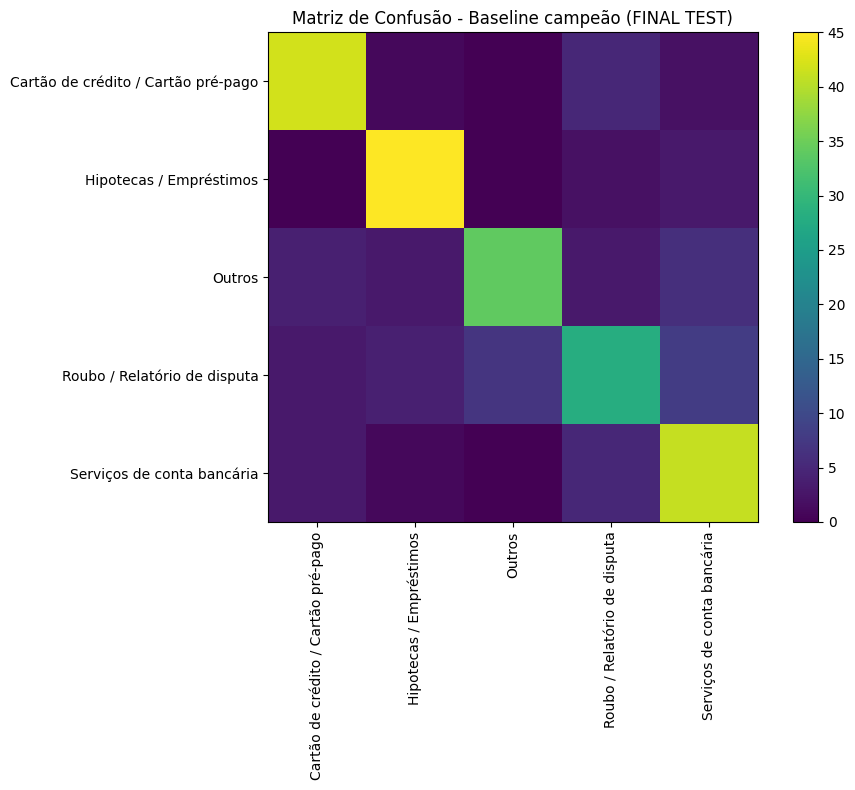

In [19]:
print(classification_report(y_test_true, y_test_pred_baseline))

LABELS = sorted(df[target_col].unique().tolist())
cm = confusion_matrix(y_test_true, y_test_pred_baseline, labels=LABELS)

plt.figure(figsize=(10,8))
plt.imshow(cm)
plt.title("Matriz de Confusão - Baseline campeão (FINAL TEST)")
plt.xticks(ticks=np.arange(len(LABELS)), labels=LABELS, rotation=90)
plt.yticks(ticks=np.arange(len(LABELS)), labels=LABELS)
plt.colorbar()
plt.tight_layout()
plt.show()

## Pipeline completo do modelo campeão

In [20]:
# PIPELINE CAMPEÃO (BASELINE) - pronto para produção
champion_pipeline = baseline_champion

# Treino final
champion_pipeline.fit(final_train["text_clean"], final_train[target_col])

# Predição final
y_pred = champion_pipeline.predict(final_test["text_clean"])
f1_final = f1_score(final_test[target_col], y_pred, average="weighted")
print("F1_weighted (FINAL TEST) - Campeão:", f1_final)

# Salvar pipeline (opcional)
import joblib
joblib.dump(champion_pipeline, "champion_pipeline.joblib")
print("Pipeline salvo em champion_pipeline.joblib")

F1_weighted (FINAL TEST) - Campeão: 0.7567543714982045
Pipeline salvo em champion_pipeline.joblib


## Resumo final

In [21]:
print("\n" + "="*70)
print("RESUMO FINAL DA ENTREGA - QuantumFinance")
print("="*70)
print(f"Pipeline Campeão: {baseline_champion_name}")
print(f"F1 Score no TESTE FINAL: {f1_final:.4f}")
print(f"Dados utilizados:")
print(f"   - Treino: {len(final_train)} amostras")
print(f"   - Validação: {len(final_val)} amostras")
print(f"   - Teste: {len(final_test)} amostras")
print(f"Classes: {len(LABELS)} ({', '.join(LABELS[:3])}...)")
print("="*70)


RESUMO FINAL DA ENTREGA - QuantumFinance
Pipeline Campeão: TFIDF + LogisticRegression
F1 Score no TESTE FINAL: 0.7568
Dados utilizados:
   - Treino: 250 amostras
   - Validação: 250 amostras
   - Teste: 250 amostras
Classes: 5 (Cartão de crédito / Cartão pré-pago, Hipotecas / Empréstimos, Outros...)


## Atividade 2 (Extra)

Esta é uma atividade extra que poderá recuperar até 2 pontos na nota final do trabalho.

1. Faça um fine-tuning de um modelo de LLM para gerar um classificador de assuntos

2. Compare os resultados obtidos em cada etapa deste trabalho e também com relação aos resultados obtidos na disciplina de NLP.

In [22]:
# CARREGANDO O DATA FRAME
import pandas as pd
df = pd.read_csv('https://dados-ml-pln.s3.sa-east-1.amazonaws.com/tickets_reclamacoes_classificados.csv', delimiter=';')

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21072 entries, 0 to 21071
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   id_reclamacao         21072 non-null  int64 
 1   data_abertura         21072 non-null  object
 2   categoria             21072 non-null  object
 3   descricao_reclamacao  21072 non-null  object
dtypes: int64(1), object(3)
memory usage: 658.6+ KB


Bom desenvolvimento!